In [1]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.7 MB/s eta 0:00:00


In [22]:
from google.colab import files
uploaded= files.upload()

Saving I01.atr to I01 (1).atr
Saving I01.dat to I01 (1).dat
Saving I01.hea to I01 (1).hea
Saving I02.atr to I02 (1).atr
Saving I02.dat to I02 (1).dat
Saving I02.hea to I02 (1).hea
Saving I03.atr to I03 (1).atr
Saving I03.dat to I03 (1).dat
Saving I03.hea to I03 (1).hea
Saving I04.atr to I04.atr
Saving I04.dat to I04.dat
Saving I04.hea to I04.hea
Saving I05.atr to I05.atr
Saving I05.dat to I05.dat
Saving I05.hea to I05.hea
Saving I06.atr to I06.atr
Saving I06.dat to I06.dat
Saving I06.hea to I06.hea
Saving I07.atr to I07.atr
Saving I07.dat to I07.dat
Saving I07.hea to I07.hea
Saving I08.atr to I08.atr
Saving I08.dat to I08.dat
Saving I08.hea to I08.hea
Saving I09.atr to I09.atr
Saving I09.dat to I09.dat
Saving I09.hea to I09.hea
Saving I10.atr to I10.atr
Saving I10.dat to I10.dat
Saving I10.hea to I10.hea


In [3]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

In [4]:
recording=wfdb.rdrecord("I01")
print(recording)
print('sampling frequency:',recording.fs)
print('number of signals:', recording.n_sig)
print('signal length:', recording.sig_len)
print('signal name:', recording.sig_name)
ecg=recording.p_signal
print("ECG shape:", ecg.shape)

leadII=ecg[:,1]
duration=10
f=recording.fs
N=int(duration*f)
time= np.arange(N)/f

sampling frequency: 257
number of signals: 12
signal length: 462600
signal name: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
ECG shape: (462600, 12)


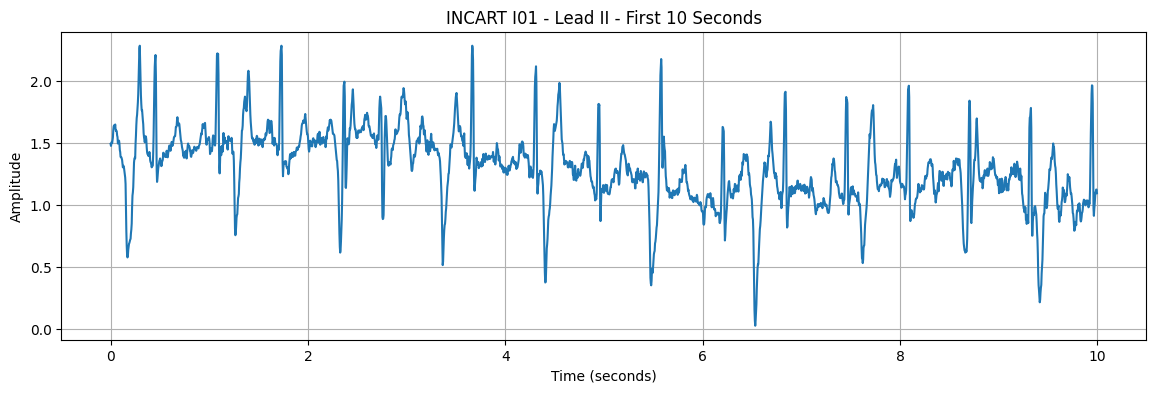

In [5]:


plt.figure(figsize=(14, 4))

plt.plot(time, leadII[:N])

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("INCART I01 - Lead II - First 10 Seconds")
plt.grid(True)

plt.show()

#Load annotated signal and plot the signal

N 114
N 277
N 442
N 608
V 710
N 941
N 1106
N 1269
N 1435
N 1596
N 1756
N 1914
N 2076
N 2237
N 2393
N 2557
V 2656
N 2885
N 3042
N 3203


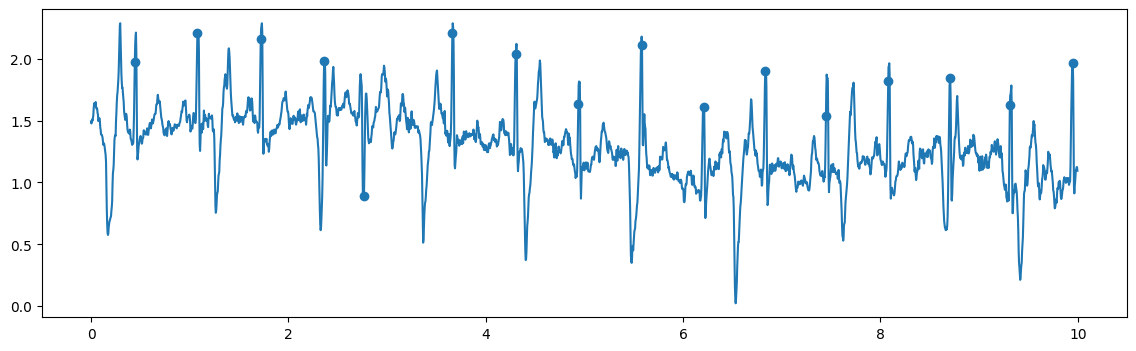

In [6]:
annotation= wfdb.rdann('I01','atr')
for i in range(20):
  print(annotation.symbol[i], annotation.sample[i])

ann_time=annotation.sample/f
mask=ann_time<duration
ann_amplitude= leadII[annotation.sample[mask]]
ann_time_10s= ann_time[mask]

plt.figure(figsize=(14,4))
plt.plot(time, leadII[:N])

plt.scatter(ann_time_10s, ann_amplitude,
label='Reference Annotation',
marker='o')

#R-Peak Detection

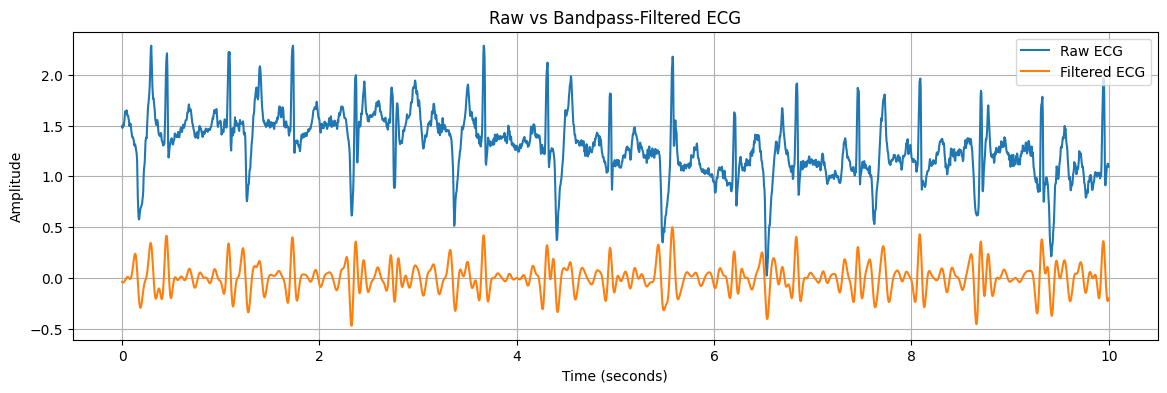

In [7]:
#Apply Filter
#filtfilt filtering does not shift the signal timing which is crucial for comparing detected R peak and Reference R-peak
from scipy.signal import butter, filtfilt
order=3
lowcut=5
highcut=15
b,a= butter(order, [lowcut, highcut], btype='bandpass', fs=f)
filtfilt_signal= filtfilt(b,a,leadII)

plt.figure(figsize=(14, 4))

plt.plot(time, leadII[:N], label='Raw ECG')
plt.plot(time, filtfilt_signal[:N], label='Filtered ECG')

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Raw vs Bandpass-Filtered ECG')
plt.legend()
plt.grid(True)

plt.show()

In [8]:
#Differentiate to get the only peak values
diff_signal=np.diff(filtfilt_signal)
derivative = np.append(diff_signal, 0)
squared_signal= derivative**2 #to make both upward and downward peaks positive

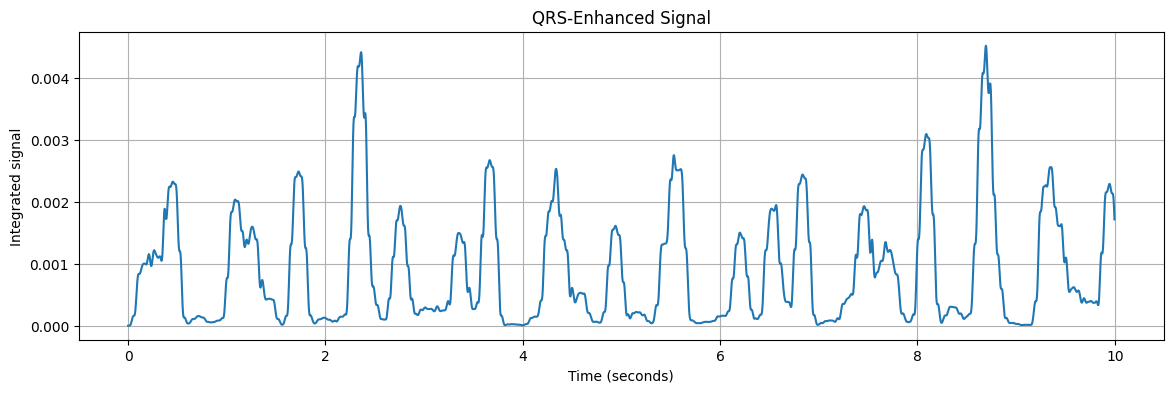

In [9]:
#Moving window integration
window_size= int(0.15*f)
moving_average = np.convolve(
    squared_signal,
    np.ones(window_size) / window_size,
    mode='same'
)
plt.figure(figsize=(14, 4))

plt.plot(time, moving_average[:N])

plt.xlabel('Time (seconds)')
plt.ylabel('Integrated signal')
plt.title('QRS-Enhanced Signal')
plt.grid(True)

plt.show()

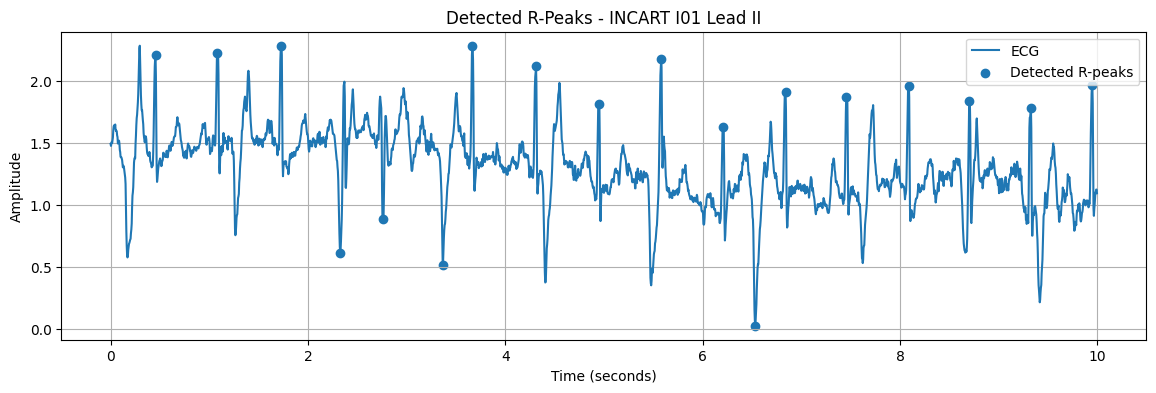

In [10]:
#Find Peaks
from scipy.signal import find_peaks

threshold = np.mean(moving_average) + 0.5 * np.std(moving_average)
peaks, properties= find_peaks(moving_average, height= threshold, distance= 0.3*f)


r_peaks=[]
radius= int(0.15*f)
for p in peaks:
  start= max(0, p-radius)
  end=min(len(leadII),p+radius+1)
  segment=leadII[start:end]
  baseline=np.mean(segment)
  local_peak=np.argmax(np.abs(segment-baseline))
  r_peaks.append(start + local_peak)

r_peaks=np.array(r_peaks)
r_peaks_10s = r_peaks[r_peaks < N]




#plot
plt.figure(figsize=(14, 4))

plt.plot(time, leadII[:N], label='ECG')

plt.scatter(
    r_peaks_10s / f,
    leadII[r_peaks_10s],
    marker='o',
    label='Detected R-peaks'
)

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Detected R-Peaks - INCART I01 Lead II')
plt.legend()
plt.grid(True)

plt.show()

#Evaluate Detected R-peak

In [11]:
probable_symbol= [
    'N', 'L', 'R', 'A', 'a', 'J', 'S',
    'V', 'F', 'e', 'j', 'E', '/', 'f', 'Q'
]
reference_beats = []
for sample, symbol in zip(annotation.sample, annotation.symbol):
  if symbol in probable_symbol:
    reference_beats.append(sample)

reference_beats=np.array(reference_beats)

print("Total annotations:", len(annotation.sample))
print("Reference beats:", len(reference_beats))
print("First 10 reference beats:", reference_beats[:10])

#match the detected peaks with reference peak
tolerance = int(0.15 * f)

matched_reference = set()
TP = 0

for detected in r_peaks:

    differences = np.abs(reference_beats - detected)

    closest = np.argmin(differences)

    if differences[closest] <= tolerance and closest not in matched_reference:

        TP += 1
        matched_reference.add(closest)

FP = len(r_peaks) - TP
FN = len(reference_beats) - TP

print("Reference beats:", len(reference_beats))
print("Detected beats:", len(r_peaks))

print("TP:", TP)
print("FP:", FP)
print("FN:", FN)

sensitivity = TP / (TP + FN)
precision = TP / (TP + FP)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Precision:   {precision * 100:.2f}%")
print(f"F1 Score:    {f1:.4f}")

Total annotations: 2757
Reference beats: 2757
First 10 reference beats: [ 114  277  442  608  710  941 1106 1269 1435 1596]
Reference beats: 2757
Detected beats: 2786
TP: 2560
FP: 226
FN: 197
Sensitivity: 92.85%
Precision:   91.89%
F1 Score:    0.9237


# Introduce different types of noise to ECG

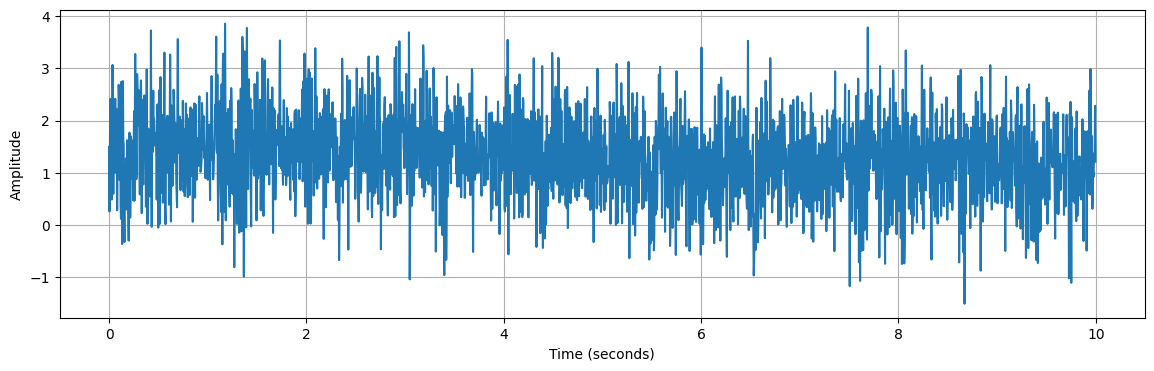

In [12]:
# Baseline wander (It is slow fluctuation of ECG signal due to breathing or body movement)
t_full= np.arange(len(leadII))/f
baseline_wander= np.sin(2*np.pi*0.3*t_full)
ecg_baseline= leadII+baseline_wander

# Power line interference : noise introduced to ECG signal at 50 Hz (European standard) from power line.
powerline_interference= np.sin(2*np.pi*50*t_full)
ecg_powerline_interference= leadII+powerline_interference

# EMG like noise: Due to muscle activity less likely noise than power line interference imposed on ECG signal. It is a random signal in the range of 20 to 100 Hz. Initially a broadband noise signal is genereated then using a filter comprised to mentioned frequency range.
white_noise= np.random.randn(len(leadII))
b_emg, a_emg= butter(3, [20,100], btype='bandpass', fs=f)
ecg_emg_noise= filtfilt(b_emg, a_emg, white_noise)
ecg_emg= leadII+ecg_emg_noise

#Motion Artifact : it is due to electrode or wire movement, a irregular , low frequency noise gets imposed with ECG signal.
b_motion, a_motion= butter(3, 2, btype='lowpass', fs=f)
motion_artifact= filtfilt(b_motion, a_motion, white_noise)
ecg_motion= leadII+motion_artifact

#plot
plt.figure(figsize=(14,4))
#plt.plot(time,ecg_baseline[:N])
#plt.plot(time,ecg_powerline_interference[:N])
plt.plot(time, ecg_emg[:N])
#plt.plot(time,ecg_motion[:N])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


# Noise Strength Control

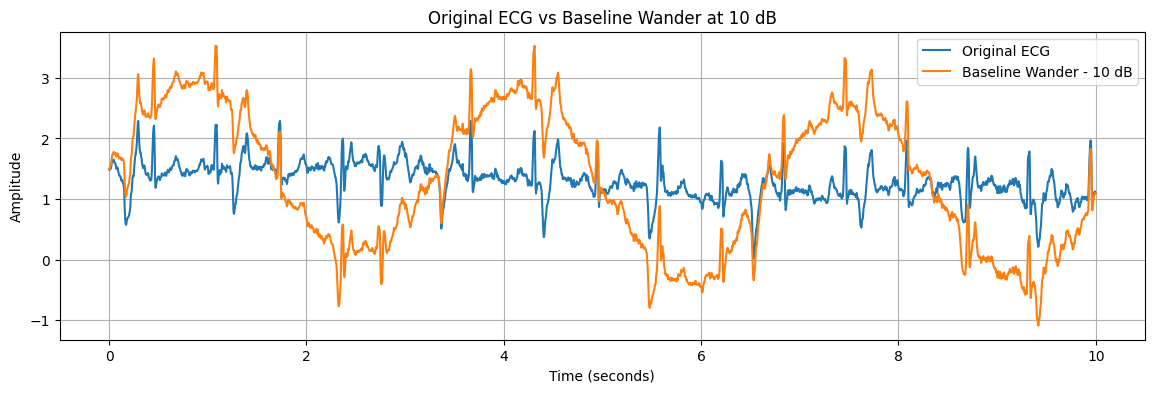

In [13]:
def noise_at_snr (ecg_signal, snr, noise_power):
  ecg_centered= ecg_signal- np.mean(ecg_signal) #remove ecg mean
  signal_power= np.mean(ecg_centered**2)

  noise_centered= noise_power-np.mean(noise_power) #remove noise mean for signal to noise ratio calculation
  existing_noise=np.mean(noise_centered**2)

  required_noise=signal_power/10**(snr/10) #SNR=10log(Ps/Pn)
  scale= np.sqrt(required_noise/existing_noise)
  scaled_noise= noise_centered*scale
  noisy_ecg= ecg_signal+ scaled_noise
  return(noisy_ecg, scaled_noise)

ecg_10db, baseline_wander_10db= noise_at_snr(leadII, 10, baseline_wander) #plot one noise to verify

#plot
plt.figure(figsize=(14, 4))

plt.plot(time, leadII[:N], label="Original ECG")
plt.plot(time, ecg_10db[:N], label="Baseline Wander - 10 dB")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Original ECG vs Baseline Wander at 10 dB")
plt.legend()
plt.grid(True)
plt.show()

In [14]:

#for all type noise
all_noisy_ecg = {}

noise_types = {
    "Baseline": baseline_wander,
    "Powerline": powerline_interference,
    "EMG": ecg_emg_noise,
    "Motion": motion_artifact
}
snr_level = [20, 10, 5, 0, -5]
for noise_name, noise_signal in noise_types.items():

    all_noisy_ecg[noise_name] = {}

    for snr_db in snr_level:

        noisy_ecg, scaled_noise = noise_at_snr(
            leadII,
            snr_db,
            noise_signal,
        )

        all_noisy_ecg[noise_name][snr_db] = noisy_ecg


# clean the signals using filters

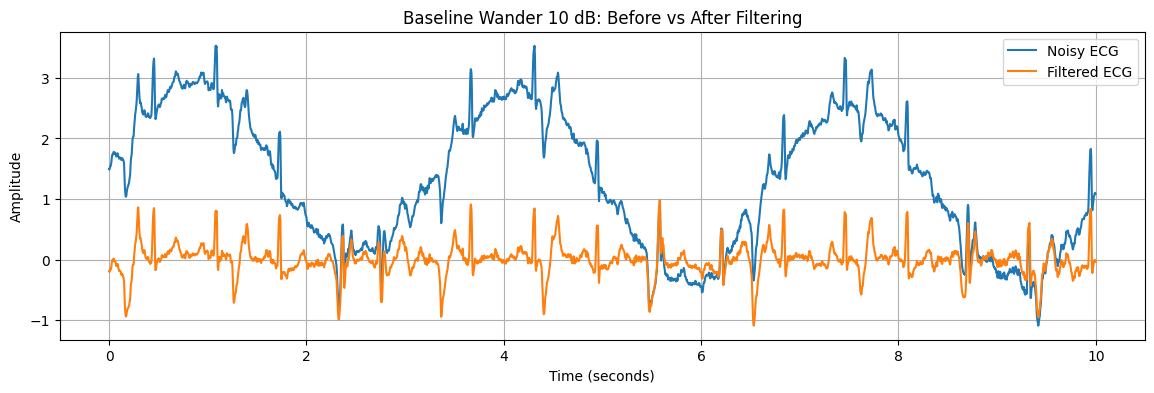

In [15]:
from scipy.signal import butter, filtfilt, iirnotch

#to clean baseline wander apply a high pass filter
def clean_baseline(ecg_signal):
  b,a= butter(3, 0.5, btype='highpass', fs=f)
  filtered= filtfilt(b,a, ecg_signal)
  return filtered
#to remove power line interference using notch filter. it is used to remove a frequency range of 30-50 Hz
def clean_powerline(ecg_signal):
  b,a= iirnotch(50,30, fs=f)
  filtered= filtfilt(b,a, ecg_signal)
  return filtered

#EMG noise > low pass filter
def clean_emgnoise(ecg_signal):
  b,a= butter(3, 20, btype='lowpass', fs=f)
  filtered= filtfilt(b,a, ecg_signal)
  return filtered
#motion artifact > high pass
def clean_motion(ecg_signal):
  b,a= butter(3, 0.5, btype='highpass', fs=f)
  filtered= filtfilt(b,a, ecg_signal)
  return filtered
#to check a filter
baseline_noise= all_noisy_ecg['Baseline'][10]
filtered_noise= clean_baseline(baseline_noise)

plt.figure(figsize=(14, 4))

plt.plot(
    time,
    baseline_noise[:N],
    label="Noisy ECG"
)

plt.plot(
    time,
    filtered_noise[:N],
    label="Filtered ECG"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Baseline Wander 10 dB: Before vs After Filtering")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
#apply filters
all_filtered_ecg={}

for noise_name in noise_types:
  all_filtered_ecg[noise_name]={}
  for snr_db in snr_level:
    noisy_ecg=all_noisy_ecg[noise_name][snr_db]
    if noise_name=='Baseline':
      filtered_ecg= clean_baseline(noisy_ecg)
    elif noise_name=='Powerline':
      filtered_noise= clean_powerline(noisy_ecg)
    elif noise_name=='EMG':
      filtered_noise= clean_emgnoise(noisy_ecg)
    elif noise_name=='Motion':
      filtered_noise= clean_motion(noisy_ecg)
    all_filtered_ecg[noise_name][snr_db] = filtered_noise





# Robustness Check

In [17]:
#detection of R-peaks using function so that multiple signals can be examined at once
def detect_rpeaks(ecg_signal, f):

    # Bandpass filter
    b, a = butter(
        3,
        [5, 15],
        btype='bandpass',
        fs=f
    )

    filtered_ecg = filtfilt(b, a, ecg_signal)

    # Derivative
    derivative = np.diff(filtered_ecg)
    derivative = np.append(derivative, 0)

    # Squaring
    squared = derivative ** 2

    # Moving-window integration
    window_size = int(0.15 * f)

    moving_average = np.convolve(
        squared,
        np.ones(window_size) / window_size,
        mode='same'
    )

    # Threshold
    threshold = np.mean(moving_average) + 0.5 * np.std(moving_average)

    # Candidate QRS regions
    candidate_peaks, _ = find_peaks(
        moving_average,
        height=threshold,
        distance=int(0.3 * f)
    )

    # Locate R/QRS peak in original input signal
    search_radius = int(0.15 * f)

    r_peaks = []

    for peak in candidate_peaks:

        start = max(0, peak - search_radius)
        end = min(len(ecg_signal), peak + search_radius + 1)

        segment = ecg_signal[start:end]

        local_baseline = np.median(segment)

        local_r = np.argmax(
            np.abs(segment - local_baseline)
        )

        r_peaks.append(start + local_r)

    return np.array(r_peaks)




In [18]:
# also repeat evaluation using function
def evaluate_rpeaks(reference_beats, detected_peaks, f):
  tolerance= int(0.15*f)
  TP= 0
  matched_reference= set()
  for detected in detected_peaks:
    differences = np.abs(reference_beats- detected)
    closest = np.argmin(differences)
    if (differences[closest]<=tolerance and closest not in matched_reference):
      TP += 1
      matched_reference.add(closest)


  FP= len(detected_peaks)-TP
  FN= len(reference_beats)-TP
  sensitivity = TP / (TP + FN)
  precision = TP / (TP + FP)

  if sensitivity + precision > 0:
    f1 = 2 * sensitivity * precision / (sensitivity + precision)
  else:
    f1 = 0

  return sensitivity, precision, f1

#to test
test_peaks = detect_rpeaks(leadII, f)

sensitivity, precision, f1 = evaluate_rpeaks(
    test_peaks,
    reference_beats,
    f
)

print("Sensitivity:", sensitivity)
print("Precision:", precision)
print("F1:", f1)



Sensitivity: 0.9180093089867526
Precision: 0.9299963728690606
F1: 0.923963963963964


In [19]:
#store the result
results = []
for noise_name in noise_types:

    for snr_db in snr_level:

        # Get noisy ECG
        noisy_ecg = all_noisy_ecg[noise_name][snr_db]

        # Get filtered ECG
        filtered_ecg = all_filtered_ecg[noise_name][snr_db]

        noisy_peaks = detect_rpeaks(
            noisy_ecg,
            f
        )
        #get R-peaks

        filtered_peaks = detect_rpeaks(
            filtered_ecg,
            f
        )
        #evaluate for noisy
        sens_noisy, prec_noisy, f1_noisy = evaluate_rpeaks(
            noisy_peaks,
            reference_beats,
            f
        )
        #evaluate for filtered
        sens_filtered, prec_filtered, f1_filtered = evaluate_rpeaks(
            filtered_peaks,
            reference_beats,
            f
        )
        #store the result
        results.append({
            "Noise": noise_name,
            "SNR": snr_db,

            "Sensitivity_Noisy": sens_noisy,
            "Precision_Noisy": prec_noisy,
            "F1_Noisy": f1_noisy,

            "Sensitivity_Filtered": sens_filtered,
            "Precision_Filtered": prec_filtered,
            "F1_Filtered": f1_filtered
        })
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Noise,SNR,Sensitivity_Noisy,Precision_Noisy,F1_Noisy,Sensitivity_Filtered,Precision_Filtered,F1_Filtered
0,Baseline,20,0.917293,0.929271,0.923243,0.920874,0.932898,0.926847
1,Baseline,10,0.903688,0.915488,0.909550,0.920874,0.932898,0.926847
2,Baseline,5,0.849982,0.861081,0.855495,0.920874,0.932898,0.926847
3,Baseline,0,0.738632,0.748277,0.743423,0.920874,0.932898,0.926847
4,Baseline,-5,0.663086,0.671745,0.667387,0.920874,0.932898,0.926847
5,Powerline,20,0.917293,0.929271,0.923243,0.918009,0.929996,0.923964
6,Powerline,10,0.915861,0.927820,0.921802,0.918009,0.929996,0.923964
7,Powerline,5,0.914337,0.925281,0.919776,0.918009,0.929996,0.923964
8,Powerline,0,0.916517,0.923830,0.920159,0.918009,0.929996,0.923964
9,Powerline,-5,0.916303,0.837867,0.875332,0.918309,0.929634,0.923937


## with multiple Recording


In [38]:
# ============================================================
# STEP 9 — MULTI-RECORD ROBUSTNESS EXPERIMENT
# ============================================================

# Records with baseline F1 >= 0.90
selected_records = [
    "I01", "I02", "I03",
    "I06", "I07", "I08"
]

# SNR levels
snr_level = [20, 10, 5, 0, -5]

# Store all results
multi_results = []


# ============================================================
# LOOP THROUGH EACH RECORD
# ============================================================

for record_name in selected_records:

    print("Processing:", record_name)

    # --------------------------------------------------------
    # 1. Load ECG and reference annotations
    # --------------------------------------------------------

    ecg, fs, reference = load_incart_record(record_name)

    # Create time axis for noise generation
    t = np.arange(len(ecg)) / fs


    # --------------------------------------------------------
    # 2. Generate noise signals
    # --------------------------------------------------------

    # Baseline wander: 0.3 Hz
    baseline_noise = np.sin(
        2 * np.pi * 0.3 * t
    )

    # Power-line interference: 50 Hz
    powerline_noise = np.sin(
        2 * np.pi * 50 * t
    )

    # EMG-like noise: random 20–100 Hz
    white_noise = np.random.randn(len(ecg))

    b_emg, a_emg = butter(
        3,
        [20, 100],
        btype="bandpass",
        fs=fs
    )

    emg_noise = filtfilt(
        b_emg,
        a_emg,
        white_noise
    )

    # Motion artifact: random low-frequency noise
    motion_random = np.random.randn(len(ecg))

    b_motion, a_motion = butter(
        3,
        2,
        btype="lowpass",
        fs=fs
    )

    motion_noise = filtfilt(
        b_motion,
        a_motion,
        motion_random
    )


    # Put the four noises together
    record_noise_types = {
        "Baseline": baseline_noise,
        "Powerline": powerline_noise,
        "EMG": emg_noise,
        "Motion": motion_noise
    }


    # ========================================================
    # 3. LOOP THROUGH EACH NOISE TYPE
    # ========================================================

    for noise_name, noise_signal in record_noise_types.items():

        # ====================================================
        # 4. LOOP THROUGH EACH SNR
        # ====================================================

        for snr_db in snr_level:

            # -----------------------------------------------
            # Add noise at desired SNR
            # -----------------------------------------------

            noisy_ecg, scaled_noise = noise_at_snr(
                ecg,
                snr_db,
                noise_signal
            )


            # -----------------------------------------------
            # Apply appropriate filter
            # -----------------------------------------------

            if noise_name == "Baseline":

                filtered_ecg = clean_baseline(
                    noisy_ecg
                )

            elif noise_name == "Powerline":

                filtered_ecg = clean_powerline(
                    noisy_ecg
                )

            elif noise_name == "EMG":

                filtered_ecg = clean_emgnoise(
                    noisy_ecg
                )

            elif noise_name == "Motion":

                filtered_ecg = clean_motion(
                    noisy_ecg
                )


            # -----------------------------------------------
            # Detect R-peaks
            # -----------------------------------------------

            noisy_peaks = detect_rpeaks(
                noisy_ecg,
                fs
            )

            filtered_peaks = detect_rpeaks(
                filtered_ecg,
                fs
            )


            # -----------------------------------------------
            # Evaluate NOISY ECG
            # -----------------------------------------------

            sens_noisy, prec_noisy, f1_noisy = evaluate_rpeaks(
                reference,
                noisy_peaks,
                fs
            )


            # -----------------------------------------------
            # Evaluate FILTERED ECG
            # -----------------------------------------------

            sens_filtered, prec_filtered, f1_filtered = evaluate_rpeaks(
                reference,
                filtered_peaks,
                fs
            )


            # -----------------------------------------------
            # Store result
            # -----------------------------------------------

            multi_results.append({

                "Record": record_name,
                "Noise": noise_name,
                "SNR": snr_db,

                "Sensitivity_Noisy": sens_noisy,
                "Precision_Noisy": prec_noisy,
                "F1_Noisy": f1_noisy,

                "Sensitivity_Filtered": sens_filtered,
                "Precision_Filtered": prec_filtered,
                "F1_Filtered": f1_filtered

            })


# ============================================================
# 5. Convert results to DataFrame
# ============================================================

multi_results_df = pd.DataFrame(multi_results)

print("Total experimental conditions:",
      len(multi_results_df))

multi_results_df

Processing: I01
Processing: I02
Processing: I03
Processing: I06
Processing: I07
Processing: I08
Total experimental conditions: 120


,Record,Noise,SNR,Sensitivity_Noisy,Precision_Noisy,F1_Noisy,Sensitivity_Filtered,Precision_Filtered,F1_Filtered
0,I01,Baseline,20,0.929271,0.917293,0.923243,0.932898,0.920874,0.926847
1,I01,Baseline,10,0.915488,0.903688,0.909550,0.932898,0.920874,0.926847
2,I01,Baseline,5,0.861081,0.849982,0.855495,0.932898,0.920874,0.926847
3,I01,Baseline,0,0.748277,0.738632,0.743423,0.932173,0.920158,0.926126
4,I01,Baseline,-5,0.671745,0.663086,0.667387,0.931447,0.919441,0.925405
...,...,...,...,...,...,...,...,...,...
115,I08,Motion,20,0.992492,0.998584,0.995528,0.992492,0.998584,0.995528
116,I08,Motion,10,0.992023,0.998111,0.995058,0.992492,0.998584,0.995528
117,I08,Motion,5,0.989676,0.995751,0.992704,0.990615,0.996695,0.993646
118,I08,Motion,0,0.961520,0.966966,0.964235,0.963867,0.969325,0.966588


In [39]:
print(multi_results_df.shape)
multi_results_df.head(10)

(120, 9)


,Record,Noise,SNR,Sensitivity_Noisy,Precision_Noisy,F1_Noisy,Sensitivity_Filtered,Precision_Filtered,F1_Filtered
0,I01,Baseline,20,0.929271,0.917293,0.923243,0.932898,0.920874,0.926847
1,I01,Baseline,10,0.915488,0.903688,0.909550,0.932898,0.920874,0.926847
2,I01,Baseline,5,0.861081,0.849982,0.855495,0.932898,0.920874,0.926847
3,I01,Baseline,0,0.748277,0.738632,0.743423,0.932173,0.920158,0.926126
4,I01,Baseline,-5,0.671745,0.663086,0.667387,0.931447,0.919441,0.925405
5,I01,Powerline,20,0.929271,0.917293,0.923243,0.929996,0.918009,0.923964
6,I01,Powerline,10,0.927820,0.915861,0.921802,0.929996,0.918009,0.923964
7,I01,Powerline,5,0.925281,0.914337,0.919776,0.929996,0.918009,0.923964
8,I01,Powerline,0,0.923830,0.916517,0.920159,0.929996,0.918009,0.923964
9,I01,Powerline,-5,0.837867,0.916303,0.875332,0.929634,0.918309,0.923937


# Mean performance across the 6 records

In [41]:

summary_df = (
    multi_results_df
    .groupby(["Noise", "SNR"])[
        [
            "Sensitivity_Noisy",
            "Precision_Noisy",
            "F1_Noisy",
            "Sensitivity_Filtered",
            "Precision_Filtered",
            "F1_Filtered"
        ]
    ]
    .mean()
    .reset_index()
)

# Arrange SNR from high to low
summary_df["SNR"] = pd.Categorical(
    summary_df["SNR"],
    categories=[20, 10, 5, 0, -5],
    ordered=True
)

summary_df = summary_df.sort_values(
    ["Noise", "SNR"]
).reset_index(drop=True)

summary_df.round(3)

,Noise,SNR,Sensitivity_Noisy,Precision_Noisy,F1_Noisy,Sensitivity_Filtered,Precision_Filtered,F1_Filtered
0,Baseline,20,0.965,0.981,0.973,0.966,0.983,0.974
1,Baseline,10,0.960,0.976,0.968,0.966,0.983,0.974
2,Baseline,5,0.928,0.943,0.935,0.966,0.983,0.974
3,Baseline,0,0.827,0.839,0.833,0.966,0.982,0.974
4,Baseline,-5,0.757,0.767,0.761,0.966,0.982,0.974
5,EMG,20,0.960,0.977,0.968,0.960,0.980,0.970
6,EMG,10,0.944,0.966,0.955,0.952,0.977,0.964
7,EMG,5,0.916,0.952,0.933,0.935,0.970,0.951
8,EMG,0,0.846,0.886,0.865,0.879,0.930,0.902
9,EMG,-5,0.735,0.774,0.754,0.769,0.823,0.794


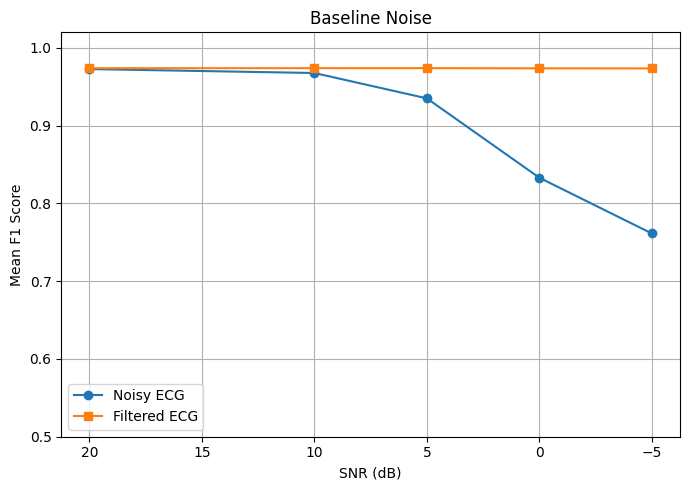

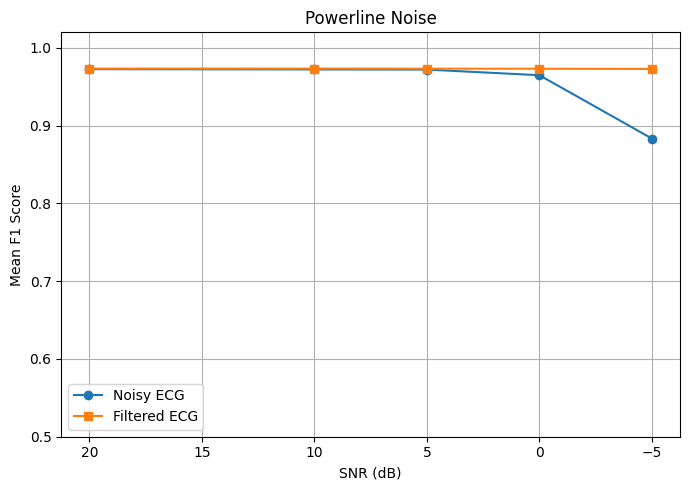

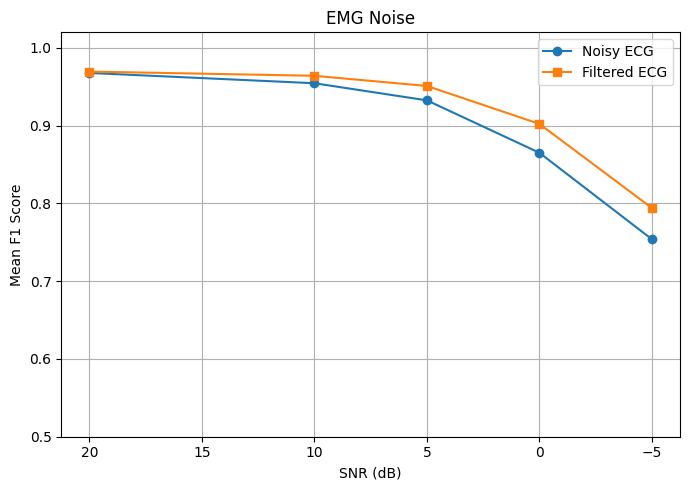

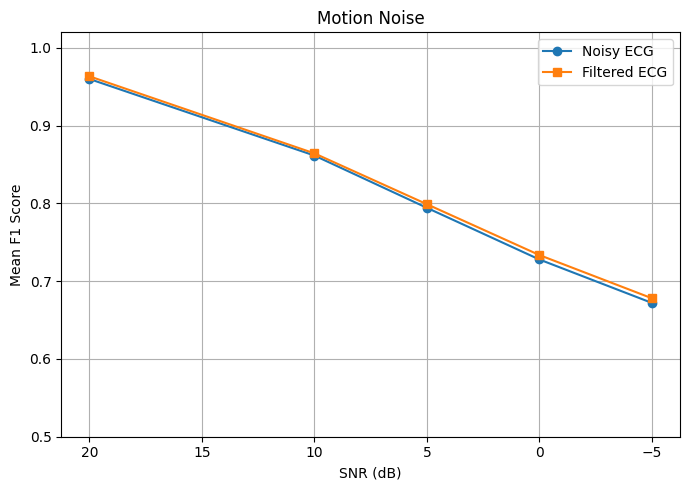

In [42]:


import matplotlib.pyplot as plt

noise_types_plot = ["Baseline", "Powerline", "EMG", "Motion"]

# Correct SNR order
snr_order = [20, 10, 5, 0, -5]

for noise_name in noise_types_plot:

    # Select one noise type
    data = summary_df[
        summary_df["Noise"] == noise_name
    ].copy()

    # Arrange SNR correctly
    data["SNR"] = pd.Categorical(
        data["SNR"],
        categories=snr_order,
        ordered=True
    )

    data = data.sort_values("SNR")

    # Create separate figure
    plt.figure(figsize=(7, 5))

    # Noisy ECG
    plt.plot(
        data["SNR"].astype(int),
        data["F1_Noisy"],
        marker="o",
        label="Noisy ECG"
    )

    # Filtered ECG
    plt.plot(
        data["SNR"].astype(int),
        data["F1_Filtered"],
        marker="s",
        label="Filtered ECG"
    )

    plt.xlabel("SNR (dB)")
    plt.ylabel("Mean F1 Score")
    plt.title(f"{noise_name} Noise")

    plt.ylim(0.5, 1.02)

    # Show 20 dB → -5 dB from left to right
    plt.gca().invert_xaxis()

    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()

In [43]:
# ============================================================
# STEP 10C — FINAL STATISTICAL SUMMARY
# Mean ± Standard Deviation across the 6 ECG records
# ============================================================

# Calculate mean and SD for each Noise × SNR condition
final_summary = (
    multi_results_df
    .groupby(["Noise", "SNR"])
    .agg(
        F1_Noisy_Mean=("F1_Noisy", "mean"),
        F1_Noisy_SD=("F1_Noisy", "std"),

        F1_Filtered_Mean=("F1_Filtered", "mean"),
        F1_Filtered_SD=("F1_Filtered", "std"),

        Sensitivity_Noisy_Mean=("Sensitivity_Noisy", "mean"),
        Sensitivity_Filtered_Mean=("Sensitivity_Filtered", "mean"),

        Precision_Noisy_Mean=("Precision_Noisy", "mean"),
        Precision_Filtered_Mean=("Precision_Filtered", "mean")
    )
    .reset_index()
)

# Correct SNR order
snr_order = [20, 10, 5, 0, -5]

final_summary["SNR"] = pd.Categorical(
    final_summary["SNR"],
    categories=snr_order,
    ordered=True
)

final_summary = final_summary.sort_values(
    ["Noise", "SNR"]
).reset_index(drop=True)


# ============================================================
# Create Mean ± SD columns
# ============================================================

final_summary["F1_Noisy"] = (
    final_summary["F1_Noisy_Mean"].map("{:.3f}".format)
    + " ± "
    + final_summary["F1_Noisy_SD"].map("{:.3f}".format)
)

final_summary["F1_Filtered"] = (
    final_summary["F1_Filtered_Mean"].map("{:.3f}".format)
    + " ± "
    + final_summary["F1_Filtered_SD"].map("{:.3f}".format)
)


# ============================================================
# Final compact table
# ============================================================

final_table = final_summary[
    [
        "Noise",
        "SNR",
        "F1_Noisy",
        "F1_Filtered"
    ]
].copy()

final_table.columns = [
    "Noise Type",
    "SNR (dB)",
    "F1 Noisy (Mean ± SD)",
    "F1 Filtered (Mean ± SD)"
]

display(final_table)


# ============================================================
# Calculate improvement after filtering
# ============================================================

final_summary["F1_Improvement"] = (
    final_summary["F1_Filtered_Mean"]
    - final_summary["F1_Noisy_Mean"]
)

print("\nF1 improvement after filtering:\n")

display(
    final_summary[
        [
            "Noise",
            "SNR",
            "F1_Improvement"
        ]
    ].round(3)
)

,Noise Type,SNR (dB),F1 Noisy (Mean ± SD),F1 Filtered (Mean ± SD)
0,Baseline,20,0.973 ± 0.036,0.974 ± 0.035
1,Baseline,10,0.968 ± 0.044,0.974 ± 0.035
2,Baseline,5,0.935 ± 0.075,0.974 ± 0.035
3,Baseline,0,0.833 ± 0.147,0.974 ± 0.035
4,Baseline,-5,0.761 ± 0.191,0.974 ± 0.035
5,EMG,20,0.968 ± 0.037,0.970 ± 0.039
6,EMG,10,0.955 ± 0.045,0.964 ± 0.046
7,EMG,5,0.933 ± 0.061,0.951 ± 0.058
8,EMG,0,0.865 ± 0.121,0.902 ± 0.103
9,EMG,-5,0.754 ± 0.203,0.794 ± 0.193



F1 improvement after filtering:



,Noise,SNR,F1_Improvement
0,Baseline,20,0.001
1,Baseline,10,0.006
2,Baseline,5,0.039
3,Baseline,0,0.141
4,Baseline,-5,0.212
5,EMG,20,0.002
6,EMG,10,0.010
7,EMG,5,0.018
8,EMG,0,0.037
9,EMG,-5,0.040
